In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mpdaf.obj import Cube
from astropy.coordinates import SkyCoord
import sys
import os
import plotfancy as pf
from matplotlib.patches import Circle
from astropy.visualization import ZScaleInterval
from astropy.table import Table
from types import SimpleNamespace
import re
from astropy.io import ascii
from astropy import units as u

# from calculate_jiang19_metallicity import calculate_metallicity_jiang19 as cjm19
import line_ratios as lr



import logging 
logging.getLogger('mpdaf').setLevel(logging.WARNING)

pf.housestyle_rcparams()

True

In [2]:
class museCube:
    def __init__(self, path:str, cluster_ra:np.float64, cluster_dec:np.float64):
        ### attributes ###
        self.centre = SkyCoord(cluster_ra*u.deg, cluster_dec*u.deg,frame='icrs')
        self.path = path
        self.title = self._get_title()
        self.spectra = {}
        self.rest_spectra = {}
        ### initialisers ###
        self.init_cube(self.path)
        self.init_lambda()
        self.init_table()

    ### INITIALISERS ###
    def _dirmanagement(self,id):
        if not os.path.isdir(f'figs/{self.title}/{id}/balmer'):
            if not os.path.isdir(f'figs/{self.title}/{id}'):
                if not os.path.isdir(f'figs/{self.title}'):
                    if not os.path.isdir('figs'):
                        os.mkdir(f'figs')
                    os.mkdir(f'figs/{self.title}')
                os.mkdir(f'figs/{self.title}/{id}')
                os.mkdir(f'figs/{self.title}/{id}/lines')
            os.mkdir(f'figs/{self.title}/{id}/balmer')
        return True

    def _get_title(self):
        pattern = r'cubes/([^_]+)_'
        match = re.search(pattern, self.path)
        if match:
            return match.group(1)
        else:
            return 'BLANK'

    def init_cube(self, PATH):
        print(f'Loading datacube: {PATH}...')
        try:
            cube = Cube(PATH)
            print(f'Successfully loaded cube. Dimensions: {cube.shape}')
            self.cube = cube
            return True
        except FileNotFoundError:
            print(f'Error: Datacube not found at {PATH}')
            sys.exit(1)
    
    def init_lambda(self):
        self.rest_lambdas = {
        # --- Primary [OIII] and [OII] ---
        'oiii5007': 5006.84,
        'oiii4959': 4958.91,
        'oii3726':  3726.03,
        'oii3729':  3728.82,

        # --- Hydrogen Balmer Series ---
        'halpha':   6562.80,
        'hbeta':    4861.33,
        'hgamma':   4340.46,
        'hdelta':   4101.73,
        'hepsilon': 3970.08,
        'hzeta':    3889.06,
        'heta':     3835.40,

        # --- Key Diagnostic Lines ---
        'oiii4363': 4363.21,
        'neiii':    3868.75,

        # --- Low-Ionization Lines ---
        'nii6583':  6583.45,
        'nii6548':  6548.05,
        'sii6716':  6716.44,
        'sii6731':  6730.82,

        # --- Helium Lines ---
        'heii4686': 4685.68,
        'hei5876':  5875.62,
        }
        self.balmer_lambda = {
        # 'halpha':   6562.80,
        'hbeta':    4861.33,
        'hgamma':   4340.46,
        'hdelta':   4101.73,
        'hepsilon': 3970.08,
        'hzeta':    3889.06,
        'heta':     3835.40,
        }
        self.lambda_keys = {
        # --- Primary [OIII] and [OII] ---
        'oiii5007': r'[OIII] $\lambda$5007',
        'oiii4959': r'[OIII] $\lambda$4959',
        'oii3726':  r'[OII] $\lambda$3726',
        'oii3729':  r'[OII] $\lambda$3729',

        # --- Hydrogen Balmer Series ---
        'halpha':   r'H$\alpha$',
        'hbeta':    r'H$\beta$',
        'hgamma':   r'H$\gamma$',
        'hdelta':   r'H$\delta$',
        'hepsilon': r'H$\epsilon$',
        'hzeta':    r'H$\zeta$',
        'heta':     r'H$\eta$',

        # --- Key Diagnostic Lines ---
        'oiii4363': r'[OIII] $\lambda$4363',  # Auroral line
        'neiii':    r'[NeIII] $\lambda$3869',

        # --- Low-Ionization Lines ---
        'nii6583':  r'[NII] $\lambda$6583',
        'nii6548':  r'[NII] $\lambda$6548',
        'sii6716':  r'[SII] $\lambda$6716',
        'sii6731':  r'[SII] $\lambda$6731',

        # --- Helium Lines (not forbidden) ---
        'heii4686': r'HeII $\lambda$4686',
        'hei5876':  r'HeI $\lambda$5876',
        }
        return True
    
    def init_table(self, cnames=None):
        self.top = ['object_id', 'ra', 'dec','z','angdisp',
                    'Z_dir','Z_dir_e',
                    'Z_j19','Z_j19_e',
                    'R23','R23_e',
                    'mean_vel_disp','sterr_vel_disp'] 
        self.column_names = self.top if cnames==None else cnames
        self.meta = ['flux','flux_err', 'ew','ew_err', 'centroid', 'fwhm','vel_disp']
        for key, _ in self.rest_lambdas.items():
            for m in self.meta:
                self.column_names.append(key+'_'+m)

        # for key, _ in self.rest_lambdas.items():
        #     if key == 'oiii5007':
        #         continue
        #     self.column_names.append('oiii5007_'+key+'_ratio')
        #     self.column_names.append('oiii5007_'+key+'_ratio_err')

        self.ex_table = Table(names=self.column_names,dtype=([str]+(len(self.column_names)-1)*[np.float64]))
        self.ex_table.add_index('object_id')
        return True
    
    ### BASIC METHODS ###
    def extract_region_centres(self,reg_file_path): #for reading ds9 reg files
        coord_pattern = re.compile(r'\w+\(([^,]+),([^,]+),.*\)')
        centres = []
        try:
            with open(reg_file_path, 'r') as f:
                for line in f:
                    line_strip = line.strip()
                    if line_strip.startswith('#') or line_strip in ['global', 'fk5', 'icrs', 'image']:
                        continue
                    match = coord_pattern.match(line_strip)
                    if match:
                        ra_str, dec_str = match.groups()
                        try:
                            ra = float(ra_str)
                            dec = float(dec_str)
                            centres.append((ra, dec))
                        except ValueError:
                            print(f"Warning: Could not parse coordinates from line: {line_strip}")
        except FileNotFoundError:
            print(f"Error: Region file not found at {reg_file_path}")
            return None
        return centres
    
    def write_regions_to_csv(self,reg_file_path, csv_file_path):
        coordinates = self.extract_region_centres(reg_file_path)
        if coordinates is None:
            print("Could not extract coordinates. Aborting CSV write.")
            return False
        try:
            coord_table = Table(rows=coordinates, names=('ra', 'dec'))
            coord_table.write(csv_file_path, format='csv', overwrite=True)
            return True
        except Exception as e:
            print(f"An error occurred while writing with Astropy: {e}")
            return False

    def extract_spectrum(self, ra, dec, radius):
        centre = (dec, ra)
        spec = self.cube.aperture(centre, radius, is_sum=True)
        return spec
    
    def deredshift_spectrum(self, spec, z):
        spec_rest = spec.copy()
        spec_rest.wave.set_crval(spec_rest.wave.get_crval() / (1 + z))
        spec_rest.wave.set_step(spec_rest.wave.get_step() / (1 + z))
        return spec_rest
    
    def generate_gaussian_profile(self, params, num_points=500, width_factor=4.0):
        sigma = params.fwhm / (2 * np.sqrt(2 * np.log(2)))
        x_min = params.lpeak - width_factor * params.fwhm / 2
        x_max = params.lpeak + width_factor * params.fwhm / 2
        x = np.linspace(x_min, x_max, num_points)
        y = params.cont + params.peak * np.exp(-((x - params.lpeak) ** 2) / (2 * sigma ** 2))
        return np.vstack((x, y))
    
    def find_z_from_line(self, spec, zapprox, target_str:str='oiii5007'):
        target = self.rest_lambdas[target_str]
        obs_wave_guess = target * (1 + zapprox)
        fit = spec.gauss_fit(lmin=(obs_wave_guess - 20), lmax=(obs_wave_guess + 20), plot=False)
        line_z = (fit.lpeak / target) - 1
        return line_z
    
    def makeid(self, cds):
        return str(cds.ra).replace('.','pt') + str(cds.dec).replace('.','pt')
    
    def write_table(self):
        self.ex_table.write(f'{self.title}_data.csv', overwrite=True)
    
    ### PLOTTING FUNCTIONS ###
    def plot_spectrum_and_cutout(self,spec, ra, dec, id):
        title = self.title
        fig, ax = pf.create_plot(size=(8, 2))
        ax_cont = fig.add_axes((1.02, 0, 1/4, 1))
        spec.plot(ax=ax, title=fr'{title} at (RA={ra:.4f}, Dec={dec:.4f})$^\circ$', color='#ff004f')
        ax.set_xlabel(r'Wavelength, $\lambda$, [$\AA$]')
        ax.set_ylabel(r'Flux [$\times10^{-20}\,\mathrm{erg}/\AA\,s\,\mathrm{cm}^{-2}$]')

        subcube_cont = self.cube.select_lambda(7000, 7500)
        im_cont = subcube_cont.mean(axis=0)
        im_cutout = im_cont.subimage(center=(dec, ra), size=4.0)

        vmin, vmax = ZScaleInterval().get_limits(im_cutout.data)
        im_cutout.plot(ax=ax_cont, vmin=vmin, vmax=vmax, show_xlabel=False, show_ylabel=False, cmap='magma')
        ax_cont.set_xticks([])
        ax_cont.set_yticks([])

        centre_pix_yx = im_cutout.wcs.sky2pix([dec, ra], 1)[0]
        aperture_circle = Circle((centre_pix_yx[1], centre_pix_yx[0]), 3, edgecolor='white', facecolor='none', lw=2, zorder=10)
        ax_cont.add_patch(aperture_circle)

        pf.fix_plot([ax])
        fig.savefig(f'figs/{title}/{id}/spectrum.png', dpi=600, bbox_inches='tight')
        plt.close(fig)
        return True

    def plot_extracted_line(self, rest_spec, fit_params, target_str, id):
        profile = self.generate_gaussian_profile(fit_params, 500, 100)

        fig, ax = pf.create_plot(size=(4,2))

        ax.set_title('Line Fit for '+self.lambda_keys[target_str])
        
        rest_spec.plot(ax=ax, color='#ff004f')
        ax.plot(profile[0], profile[1], color='k', lw=1.4)

        ax.set_xlim([np.min(profile[0]), np.max(profile[0])])
        ax.set_xlabel(r'O$_{III}$-Calibrated Rest-$\lambda$, [$\AA$] }')
        ax.set_ylabel(r'Flux [$\times10^{-20}\,\mathrm{erg}/\AA\,s\,\mathrm{cm}^{-2}$]')

        pf.fix_plot([ax])
        fig.savefig(f'figs/{self.title}/{id}/lines/spectrum_{target_str}.png', dpi=600, bbox_inches='tight')
        plt.close(fig)

    def plot_all_lines_on_spectrum(self, rest_spec, linefits, id, ra=None, dec=None):
        fig, ax = pf.create_plot(size=(8, 2))
        if ra is not None and dec is not None:
            ax_cont = fig.add_axes((1.02, 0, 1/4, 1))

        rest_spec.plot(ax=ax, color='#ff004f', label='Spectrum')

        line_names = list(self.rest_lambdas.keys())
        
        max_peak_y = np.max(rest_spec.data)

        for i, linefit in enumerate(linefits):
            if linefit.flux != 0:
                profile = self.generate_gaussian_profile(linefit, 500, 4)
                # if not np.sum(profile[1]<0)>0:
                if linefit.peak>0:
                    ax.plot(profile[0], profile[1], color='k', lw=1.2)
                    
                    line_name = line_names[i]
                    label = self.lambda_keys[line_name]
                    
                    peak_y = linefit.cont + linefit.peak
                    if peak_y > max_peak_y:
                        max_peak_y = peak_y
                    ax.text(linefit.lpeak, peak_y * 1.05, label, ha='center', va='bottom', rotation=90, fontsize=8)
    
        ax.set_xlabel(r'Rest Wavelength, $\lambda$, [$\AA$]')
        ax.set_ylabel(r'Flux [$\times10^{-20}\,\mathrm{erg}/\AA\,s\,\mathrm{cm}^{-2}$]')

        if max_peak_y > 0:
            ax.set_ylim(bottom=-50, top=max_peak_y * 1.5)
        else:
            ax.set_ylim(bottom=-50)

        # Continuum plot part
        if ra is not None and dec is not None:
            subcube_cont = self.cube.select_lambda(7000, 7500)
            im_cont = subcube_cont.mean(axis=0)
            im_cutout = im_cont.subimage(center=(dec, ra), size=4.0)

            vmin, vmax = ZScaleInterval().get_limits(im_cutout.data)
            im_cutout.plot(ax=ax_cont, vmin=vmin, vmax=vmax, show_xlabel=False, show_ylabel=False, cmap='magma')
            ax_cont.set_xticks([])
            ax_cont.set_yticks([])

            centre_pix_yx = im_cutout.wcs.sky2pix([dec, ra], 1)[0]
            aperture_circle = Circle((centre_pix_yx[1], centre_pix_yx[0]), 3, edgecolor='white', facecolor='none', lw=2, zorder=10)
            ax_cont.add_patch(aperture_circle)

        pf.fix_plot([ax])
        fig.savefig(f'figs/{self.title}/{id}/spectrum_all_lines.png', dpi=600, bbox_inches='tight')
        plt.close(fig)
        return True
    
    def balmer_diagnostic_plot(self, rest_spec, linefits, id):

        fig, ax = pf.create_plot(size=(8, 2))

        rest_spec.plot(ax=ax, color='#ff004f', label='Spectrum')

        line_names = list(self.balmer_lambda.keys())
        fluxes = []
        
        max_peak_y = np.max(rest_spec.data)

        for i, linefit in enumerate(linefits):
            fluxes.append(linefit.flux)
            if linefit.flux != 0:
                profile = self.generate_gaussian_profile(linefit, 500, 4)
                # if not np.sum(profile[1]<0)>0:
                if linefit.peak>0:
                    ax.plot(profile[0], profile[1], color='k', lw=1.2)
                    
                    line_name = line_names[i]
                    label = self.lambda_keys[line_name]
                    
                    peak_y = linefit.cont + linefit.peak
                    if peak_y > max_peak_y:
                        max_peak_y = peak_y
                    ax.text(linefit.lpeak, peak_y * 1.05, label, ha='center', va='bottom', rotation=90, fontsize=8)

        fluxes = np.array(fluxes)
        fluxes_norm = fluxes/fluxes[0]
        flux_string = ":".join([f"{f:.2f}" for f in fluxes_norm[:5]])
        ax.set_title(r'$\beta:\gamma:\delta:\epsilon:\zeta:\nu=$'+flux_string)
        ax.set_xlabel(r'Rest Wavelength, $\lambda$, [$\AA$]')
        ax.set_ylabel(r'Flux [$\times10^{-20}\,\mathrm{erg}/\AA\,s\,\mathrm{cm}^{-2}$]')

        ax.set_ylim(bottom=-0.11*max_peak_y, top=max_peak_y * 1.5)

        ax.fill_between([0,3646], 2*[-1000], 2*[4*max_peak_y], color='#77aca2', zorder=-10, alpha=0.3)
        ax.fill_between([3646,10000], 2*[-1000], 2*[4*max_peak_y], color='#ff004f', zorder=-10, alpha=0.3)

        ax.text(3100,1.2*max_peak_y,'Continuum')
        ax.text(4600,1.2*max_peak_y,'Series')

        pf.fix_plot([ax])
        fig.savefig(f'figs/{self.title}/{id}/balmer/balmer_diag.png', dpi=600, bbox_inches='tight')
        plt.close(fig)
        return True


    ### EXTRACTION METHODS ###

    def fit_line(self,dered_spectra, target_str:str):
        target = self.rest_lambdas[target_str]
        try:
            line_fit = dered_spectra.gauss_fit(lmin=(target - 50), lmax=(target + 50),lpeak=target ,plot=False)

            # check for the validity of the fit
            sub_spec = dered_spectra.subspec(lmin=target - 15, lmax=target + 15)
            if sub_spec is not None and line_fit is not None and hasattr(line_fit, 'peak') and hasattr(line_fit, 'cont'):
                max_data_value = np.max(sub_spec.data)
                fitted_peak_value = line_fit.peak + line_fit.cont
                if fitted_peak_value > 1.5 * max_data_value:
                    raise ValueError("Fitted peak is unrealistically high.")
        except Exception:
            sub_spec = dered_spectra.subspec(lmin=target - 10, lmax=target + 10)
            
            spec_for_continuum = None
            if sub_spec is not None and len(sub_spec.shape) == 1 and sub_spec.shape[0] > 2:
                spec_for_continuum = sub_spec
            elif dered_spectra is not None and len(dered_spectra.shape) == 1 and dered_spectra.shape[0] > 2:
                spec_for_continuum = dered_spectra
            if spec_for_continuum:
                continuum = np.mean(spec_for_continuum.data)
                std_err = np.std(spec_for_continuum.data)
                
                fit_mock = SimpleNamespace(
                    flux=0.0,
                    err_flux=std_err,
                    peak=0.0,
                    cont=continuum,
                    lpeak=target,
                    fwhm=1.0,
                    err_peak=std_err,
                    err_cont=std_err,
                    err_lpeak=0.0,
                    err_fwhm=0.0
                )
                line_fit = fit_mock
        return line_fit
    
    def _prepare_and_extract_spectrum(self, coords, z_guess, rad):
        id = self.makeid(coords)
        self._dirmanagement(id=id)
        
        radec = (coords.ra.deg, coords.dec.deg)
        
        obj_spectrum = self.extract_spectrum(radec[0], radec[1], radius=rad)
        self.spectra[id] = obj_spectrum
        
        obj_z = self.find_z_from_line(obj_spectrum, z_guess)
        
        rest_spectrum = self.deredshift_spectrum(obj_spectrum, obj_z)
        self.rest_spectra[id] = rest_spectrum
        
        # Prepare initial row for the table
        obj_row = [id, radec[0], radec[1], obj_z]
        self.ex_table.add_row((obj_row + (len(self.column_names) - len(obj_row)) * [np.nan]))
        
        return id, radec, obj_spectrum, rest_spectrum
    
    # def _fix_oii(self,rest_spectrum)
        

    def _fit_all_lines(self, rest_spectrum, id, plot=True):
        linefits = []
        for linename in self.rest_lambdas.keys():
            linefit = self.fit_line(rest_spectrum, linename)
            linefits.append(linefit)
            if plot and linefit.flux != 0:
                self.plot_extracted_line(rest_spectrum, linefit, linename, id)
        return linefits
    
    def _fit_balmer_lines(self, rest_spectrum,id):
        linefits = []
        for linename in self.balmer_lambda.keys():
            linefit = self.fit_line(rest_spectrum, linename)
            linefits.append(linefit)
        return linefits

    def _update_table_with_fit_results(self, pxy, linefits):
        locd_row = pxy
        
        # Store basic fit results
        for i, linename in enumerate(self.rest_lambdas.keys()):
            rest_wl = self.rest_lambdas.get(linename)
            linefit = linefits[i]

            rest_spectrum = self.rest_spectra.get(id)

            # resn = rest_spectrum.wave.get_step() if rest_spectrum else 1
            resn = 0.7 

            locd_row[linename + '_flux'] = linefit.flux
            locd_row[linename + '_flux_err'] = linefit.err_flux
            locd_row[linename + '_fwhm'] = linefit.fwhm
            locd_row[linename + '_centroid'] = linefit.lpeak
            locd_row[linename + '_vel_disp'] = lr.get_velocity_disp(linefit.fwhm, rest_wl,resn)
            
            if linefit.cont != 0 and linefit.flux != 0:
                eqwidth = linefit.flux / np.abs(linefit.cont)
                locd_row[linename + '_ew'] = eqwidth
                locd_row[linename + '_ew_err'] = (linefit.err_flux / linefit.flux) * eqwidth
            else:
                locd_row[linename + '_ew'] = np.nan
                locd_row[linename + '_ew_err'] = np.nan

    def _correct_flux(self, pxy):
        # return True
        self.raw_table = self.ex_table.copy()
        ebv_corr = lr.get_ebv(pxy['hbeta_flux'], pxy['hgamma_flux'])
        flux_keys = [key for key in self.ex_table.colnames if key.endswith('_flux')]
        for key in flux_keys:
            linekey = key[:-5]
            flux = pxy[key].copy()
            pxy[key] = lr.correct_flux(flux,pxy[linekey+'_centroid'],ebv_corr)

    def _avg_velo_disps(self, pxy):
        global vel_keys
        vel_keys = [key for key in self.ex_table.colnames if key.endswith('_vel_disp')]
        vels = []
        for key in vel_keys:
            vels.append(pxy[key])
        vels = np.array(vels)
        # print(vels)
        pxy['mean_vel_disp'] = np.nanmean(vels)
        pxy['sterr_vel_disp'] = np.nanstd(vels)/np.sqrt(np.count_nonzero(~np.isnan(vels)))


    def _direct_mcity(self, pxy):
        metallicity, err = lr.get_metallicity_with_errors(
            pxy['oiii5007_flux'],pxy['oiii4959_flux'],pxy['oiii4363_flux'],
            pxy['oii3726_flux'],pxy['oii3729_flux'],pxy['hbeta_flux'],
            pxy['oiii5007_flux_err'],pxy['oiii4959_flux_err'],pxy['oiii4363_flux_err'],
            pxy['oii3726_flux_err'],pxy['oii3729_flux_err'],pxy['hbeta_flux_err'],
        )
        pxy['Z_dir'] = metallicity
        pxy['Z_dir_e'] = err

    def _j19_mcity(self, pxy):
        metallicity, err = lr.get_j19_with_errors(
            pxy['oiii5007_flux'],pxy['oiii4959_flux'],pxy['oii3726_flux'],
            pxy['oii3729_flux'],pxy['hbeta_flux'],
            pxy['oiii5007_flux_err'],pxy['oiii4959_flux_err'],pxy['oii3726_flux_err'],
            pxy['oii3729_flux_err'],pxy['hbeta_flux_err'],
        )
        pxy['Z_j19'] = metallicity
        pxy['Z_j19_e'] = err

    def _r23(self, pxy):
        r23, err = lr.get_R23_with_errors(
            pxy['oiii5007_flux'],pxy['oiii4959_flux'],pxy['oii3726_flux'],
            pxy['oii3729_flux'],pxy['hbeta_flux'],
            pxy['oiii5007_flux_err'],pxy['oiii4959_flux_err'],pxy['oii3726_flux_err'],
            pxy['oii3729_flux_err'],pxy['hbeta_flux_err'],
        )
        pxy['R23'] = r23
        pxy['R23_e'] = err
 
    def _update_metallicities(self, PXY):
        self._direct_mcity(PXY)
        self._j19_mcity(PXY)
        self._r23(PXY)
        return True
    
    def table_management(self, ID, LINEFITS, ANGDISP):
        pxy = self.ex_table.loc[ID]
        pxy['angdisp'] = ANGDISP*3600 # now in arcseconds
        self._update_table_with_fit_results(pxy, LINEFITS)
        self._correct_flux(pxy)
        self._update_metallicities(pxy)
        self._avg_velo_disps(pxy)
        return True

    def pick_target(self, coords, z_guess, rad, plot=True):
        id, radec, obj_spectrum, rest_spectrum = self._prepare_and_extract_spectrum(coords, z_guess, rad)
        angdisp = np.sqrt((radec[0]-self.centre.ra.deg)**2+(radec[1]-self.centre.dec.deg)**2)
        
        if plot:
            self.plot_spectrum_and_cutout(obj_spectrum, radec[0], radec[1], id)
            
        linefits = self._fit_all_lines(rest_spectrum, id, plot=plot)
        balmer_linefits = self._fit_balmer_lines(rest_spectrum, id)
        
        if plot:
            self.plot_all_lines_on_spectrum(rest_spectrum, linefits, id, radec[0], radec[1])
            self.balmer_diagnostic_plot(rest_spectrum, balmer_linefits, id)
            
        self.table_management(id,linefits, angdisp)

        # self.table_management(id,linefits)
        return True

    def stack_and_fit_spectra(self, plot=True):
        if not self.rest_spectra:
            print("No rest-frame spectra to stack.")
            return

        # Stack rest-frame spectra
        spectra_to_stack = list(self.rest_spectra.values())
        stacked_spectrum = spectra_to_stack[0].copy()
        for spec in spectra_to_stack[1:]:
            stacked_spectrum.data += spec.data

        id = 'STACK'
        self._dirmanagement(id=id)
        
        # Prepare table row for the stacked spectrum
        mean_z = np.mean([self.ex_table.loc[spec_id]['z'] for spec_id in self.rest_spectra.keys()])
        if id in self.ex_table['object_id']:
            self.ex_table.remove_row(np.where(self.ex_table['object_id'] == id)[0][0])
        obj_row = [id, np.nan, np.nan, mean_z]
        self.ex_table.add_row((obj_row + (len(self.column_names) - len(obj_row)) * [np.nan]))

        # Fit lines and update table
        linefits = self._fit_all_lines(stacked_spectrum, id, plot=plot)
        balmer_linefits = self._fit_balmer_lines(stacked_spectrum, id)
        if plot:
            self.plot_all_lines_on_spectrum(stacked_spectrum, linefits, id)
            self.balmer_diagnostic_plot(stacked_spectrum, balmer_linefits, id)
        
        self.table_management(id,linefits, np.nan)
        return True

    def process_multiple_ds9(self, csv_path):
        coord_table = Table(ascii.read(csv_path))
        all_coords = SkyCoord(coord_table['ra'] * u.deg,
                              coord_table['dec'] * u.deg,
                              frame='icrs')
        for i in range(len(all_coords)):
            csv_coords = all_coords[i]
            z_estimate = coord_table['z_est'][i]
            self.pick_target(csv_coords, z_estimate, 0.7)
        self.stack_and_fit_spectra(plot=True)
        self.write_table()

In [3]:
CUBE_PATH = '../../cubes/s780_COMBINED_CUBE_MED_FINAL.fits'
test = museCube(CUBE_PATH, 224.8697465,-18.1791560)
# test.pick_target(COORDS,Z_GUESS,RADIUS_ARCSEC)
# spec = test.extract_spectrum(COORDS.ra.deg,COORDS.dec.deg, 0.6)
test.process_multiple_ds9('s780_coords.csv')
test.ex_table

Loading datacube: ../../cubes/s780_COMBINED_CUBE_MED_FINAL.fits...
Successfully loaded cube. Dimensions: (3682, 315, 361)


object_id,ra,dec,z,angdisp,Z_dir,Z_dir_e,Z_j19,Z_j19_e,R23,R23_e,mean_vel_disp,sterr_vel_disp,oiii5007_flux,oiii5007_flux_err,oiii5007_ew,oiii5007_ew_err,oiii5007_centroid,oiii5007_fwhm,oiii5007_vel_disp,oiii4959_flux,oiii4959_flux_err,oiii4959_ew,oiii4959_ew_err,oiii4959_centroid,oiii4959_fwhm,oiii4959_vel_disp,oii3726_flux,oii3726_flux_err,oii3726_ew,oii3726_ew_err,oii3726_centroid,oii3726_fwhm,oii3726_vel_disp,oii3729_flux,oii3729_flux_err,oii3729_ew,oii3729_ew_err,oii3729_centroid,oii3729_fwhm,oii3729_vel_disp,halpha_flux,halpha_flux_err,halpha_ew,halpha_ew_err,halpha_centroid,halpha_fwhm,halpha_vel_disp,hbeta_flux,hbeta_flux_err,hbeta_ew,hbeta_ew_err,hbeta_centroid,hbeta_fwhm,hbeta_vel_disp,hgamma_flux,hgamma_flux_err,hgamma_ew,hgamma_ew_err,hgamma_centroid,hgamma_fwhm,hgamma_vel_disp,hdelta_flux,hdelta_flux_err,hdelta_ew,hdelta_ew_err,hdelta_centroid,hdelta_fwhm,hdelta_vel_disp,hepsilon_flux,hepsilon_flux_err,hepsilon_ew,hepsilon_ew_err,hepsilon_centroid,hepsilon_fwhm,hepsilon_vel_disp,hzeta_flux,hzeta_flux_err,hzeta_ew,hzeta_ew_err,hzeta_centroid,hzeta_fwhm,hzeta_vel_disp,heta_flux,heta_flux_err,heta_ew,heta_ew_err,heta_centroid,heta_fwhm,heta_vel_disp,oiii4363_flux,oiii4363_flux_err,oiii4363_ew,oiii4363_ew_err,oiii4363_centroid,oiii4363_fwhm,oiii4363_vel_disp,neiii_flux,neiii_flux_err,neiii_ew,neiii_ew_err,neiii_centroid,neiii_fwhm,neiii_vel_disp,nii6583_flux,nii6583_flux_err,nii6583_ew,nii6583_ew_err,nii6583_centroid,nii6583_fwhm,nii6583_vel_disp,nii6548_flux,nii6548_flux_err,nii6548_ew,nii6548_ew_err,nii6548_centroid,nii6548_fwhm,nii6548_vel_disp,sii6716_flux,sii6716_flux_err,sii6716_ew,sii6716_ew_err,sii6716_centroid,sii6716_fwhm,sii6716_vel_disp,sii6731_flux,sii6731_flux_err,sii6731_ew,sii6731_ew_err,sii6731_centroid,sii6731_fwhm,sii6731_vel_disp,heii4686_flux,heii4686_flux_err,heii4686_ew,heii4686_ew_err,heii4686_centroid,heii4686_fwhm,heii4686_vel_disp,hei5876_flux,hei5876_flux_err,hei5876_ew,hei5876_ew_err,hei5876_centroid,hei5876_fwhm,hei5876_vel_disp
str34,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64
224d52m17pt6016s-18d10m40pt68516s,224.871556,-18.1779681,0.6695012973895351,7.792479753831912,nan,nan,7.645659607096462,1.626264647615061e-08,792.4563368112101,0.0028231088051037085,422.301247111203,258.8037965519083,502528990.7265921,720.5323228622846,14.23289559046407,0.5933293032504053,5006.843572751841,1.5969102444246461,36.496042221449265,243418047.9798254,4518.065000538212,10.073706296359234,6.382718008564347,4958.88379975588,1.8078394684326988,42.792241502131176,107303486143.7118,1011.5910809081068,7.870259730262439,1.114749075337647,3727.8280392490024,4.299810201938652,144.9549974160158,112493288292.64012,997.8958374192196,8.60662089202981,1.1470908493447904,3727.824927011513,4.416906365566106,148.89705391921012,0.0,531.6441895650835,nan,nan,6562.8,1.0,13.853480493619768,278302678.93687004,991.4289290087277,4.120

In [4]:
CUBE_PATH2 = '../../cubes/macs0159m34_COMBINED_CUBE_MED_FINAL.fits'
test2 = museCube(CUBE_PATH2, 29.7664067,-34.2178254)
test2.process_multiple_ds9('MACS_coords.csv')
test2.ex_table

Loading datacube: ../../cubes/macs0159m34_COMBINED_CUBE_MED_FINAL.fits...
Successfully loaded cube. Dimensions: (3681, 314, 329)


object_id,ra,dec,z,angdisp,Z_dir,Z_dir_e,Z_j19,Z_j19_e,R23,R23_e,mean_vel_disp,sterr_vel_disp,oiii5007_flux,oiii5007_flux_err,oiii5007_ew,oiii5007_ew_err,oiii5007_centroid,oiii5007_fwhm,oiii5007_vel_disp,oiii4959_flux,oiii4959_flux_err,oiii4959_ew,oiii4959_ew_err,oiii4959_centroid,oiii4959_fwhm,oiii4959_vel_disp,oii3726_flux,oii3726_flux_err,oii3726_ew,oii3726_ew_err,oii3726_centroid,oii3726_fwhm,oii3726_vel_disp,oii3729_flux,oii3729_flux_err,oii3729_ew,oii3729_ew_err,oii3729_centroid,oii3729_fwhm,oii3729_vel_disp,halpha_flux,halpha_flux_err,halpha_ew,halpha_ew_err,halpha_centroid,halpha_fwhm,halpha_vel_disp,hbeta_flux,hbeta_flux_err,hbeta_ew,hbeta_ew_err,hbeta_centroid,hbeta_fwhm,hbeta_vel_disp,hgamma_flux,hgamma_flux_err,hgamma_ew,hgamma_ew_err,hgamma_centroid,hgamma_fwhm,hgamma_vel_disp,hdelta_flux,hdelta_flux_err,hdelta_ew,hdelta_ew_err,hdelta_centroid,hdelta_fwhm,hdelta_vel_disp,hepsilon_flux,hepsilon_flux_err,hepsilon_ew,hepsilon_ew_err,hepsilon_centroid,hepsilon_fwhm,hepsilon_vel_disp,hzeta_flux,hzeta_flux_err,hzeta_ew,hzeta_ew_err,hzeta_centroid,hzeta_fwhm,hzeta_vel_disp,heta_flux,heta_flux_err,heta_ew,heta_ew_err,heta_centroid,heta_fwhm,heta_vel_disp,oiii4363_flux,oiii4363_flux_err,oiii4363_ew,oiii4363_ew_err,oiii4363_centroid,oiii4363_fwhm,oiii4363_vel_disp,neiii_flux,neiii_flux_err,neiii_ew,neiii_ew_err,neiii_centroid,neiii_fwhm,neiii_vel_disp,nii6583_flux,nii6583_flux_err,nii6583_ew,nii6583_ew_err,nii6583_centroid,nii6583_fwhm,nii6583_vel_disp,nii6548_flux,nii6548_flux_err,nii6548_ew,nii6548_ew_err,nii6548_centroid,nii6548_fwhm,nii6548_vel_disp,sii6716_flux,sii6716_flux_err,sii6716_ew,sii6716_ew_err,sii6716_centroid,sii6716_fwhm,sii6716_vel_disp,sii6731_flux,sii6731_flux_err,sii6731_ew,sii6731_ew_err,sii6731_centroid,sii6731_fwhm,sii6731_vel_disp,heii4686_flux,heii4686_flux_err,heii4686_ew,heii4686_ew_err,heii4686_centroid,heii4686_fwhm,heii4686_vel_disp,hei5876_flux,hei5876_flux_err,hei5876_ew,hei5876_ew_err,hei5876_centroid,hei5876_fwhm,hei5876_vel_disp
str33,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64
29d46m30pt68004s-34d13m03pt78948s,29.7751889,-34.2177193,0.688920751978447,31.618227193942236,nan,nan,nan,nan,nan,nan,573.147851224081,353.8671360928847,16716447.892730303,459.03337461930766,112.52676394227474,5.274586743615406,5006.836390822859,1.789883495260365,41.88695757219216,5694463.618593982,644.9520843587354,32.956488646629445,7.157517007575901,4958.8421406742555,1.6697413897921798,38.918419565875695,-50.396192676630115,58.83887879510869,-1.4105673033473936,1.6468743805023165,3726.4948148040166,0.8070485336310418,13.723680929514115,1248112335.6095054,2517.994494914047,163.63482131007,55.72897072609993,3714.3617755963623,142.201091769165,4854.999934244893,0.0,131.39715162269871,nan,nan,6562.8,1.0,13.853480493619768,3929827.4356103637,95.05086844689976,45.270128467201936,2.6840839643848633,4861.336113649758,1.97880

In [5]:
dirs1 = np.concatenate([test2.ex_table['Z_dir'].data, test.ex_table['Z_dir'].data])
dirs1_e = np.concatenate([test2.ex_table['Z_dir_e'].data, test.ex_table['Z_dir_e'].data])
j19s1 = np.concatenate([test2.ex_table['Z_j19'].data, test.ex_table['Z_j19'].data])
j19s1_e = np.concatenate([test2.ex_table['Z_j19_e'].data, test.ex_table['Z_j19_e'].data])
r23s1 = np.concatenate([test2.ex_table['R23'].data, test.ex_table['R23'].data])
r23s_e = np.concatenate([test2.ex_table['R23_e'].data, test.ex_table['R23_e'].data])
loge_r23 = np.log10(r23s1)*(r23s_e/r23s1)

/var/folders/6b/x84gj0ds47n3hjglw1wq1j8m0000gn/T/ipykernel_54363/2169645756.py:3: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string "o" (-> marker='o'). The keyword argument will take precedence.
  ax.errorbar(np.log10(r23s1),j19s1, marker='x', color='#ff004f',fmt='o', markersize=5, ecolor='gray', capsize=2, yerr=j19s1_e,xerr=loge_r23 )


True

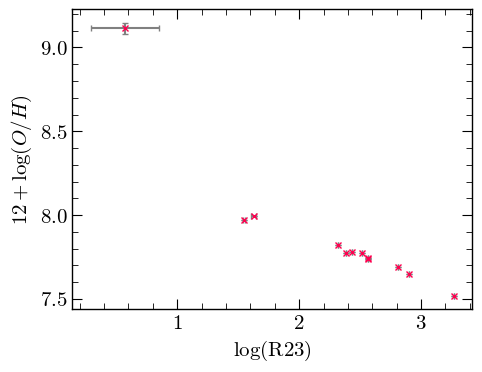

In [7]:
pf.housestyle_rcparams()
fig, ax = pf.create_plot()
ax.errorbar(np.log10(r23s1),j19s1, marker='x', color='#ff004f',fmt='o', markersize=5, ecolor='gray', capsize=2, yerr=j19s1_e,xerr=loge_r23 )
ax.set_xlabel(r'$\log(\mathrm{R23})$')
ax.set_ylabel(r'$12+\log(O/H)$')
pf.fix_plot([ax])

True

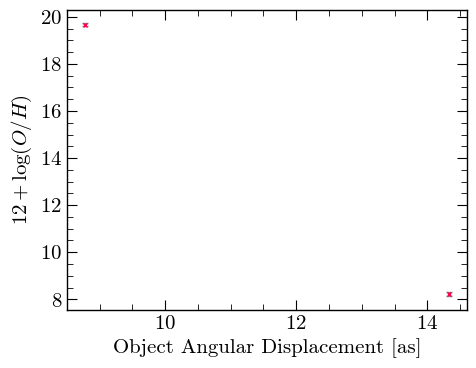

In [8]:
fig, ax = pf.create_plot()
ax.errorbar(test.ex_table['angdisp'],test.ex_table['Z_dir'], yerr=test.ex_table['Z_dir_e'] ,fmt='x', markersize=3, ecolor='gray', capsize=2,color='#ff004f')

ax.set_ylabel(r'$12+\log(O/H)$')
ax.set_xlabel(r'Object Angular Displacement [as]')

pf.fix_plot([ax])

True

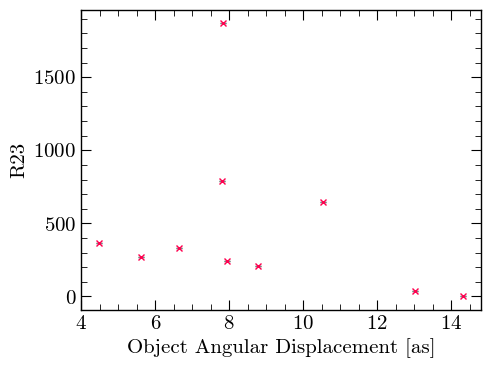

In [9]:


fig, ax = pf.create_plot()
ax.errorbar(test.ex_table['angdisp'],test.ex_table['R23'], yerr=test.ex_table['R23_e'],fmt='x', markersize=4, ecolor='gray', capsize=2,color='#ff004f')

ax.set_ylabel(r'R23')
ax.set_xlabel(r'Object Angular Displacement [as]')

pf.fix_plot([ax])

/var/folders/6b/x84gj0ds47n3hjglw1wq1j8m0000gn/T/ipykernel_54363/3320991474.py:3: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string "o" (-> marker='o'). The keyword argument will take precedence.
  ax.errorbar(np.log10(r23s1),dirs1, marker='x', color='#ff004f',fmt='o', markersize=5, ecolor='gray', capsize=2, yerr=dirs1_e,xerr=loge_r23 )


True

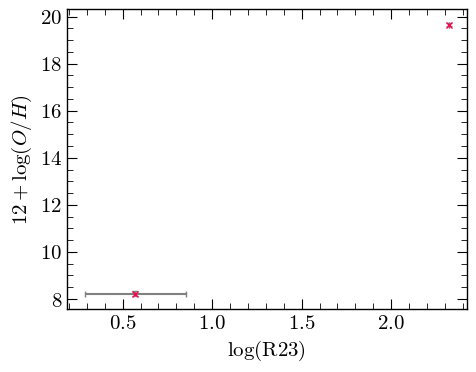

In [10]:
pf.housestyle_rcparams()
fig, ax = pf.create_plot()
ax.errorbar(np.log10(r23s1),dirs1, marker='x', color='#ff004f',fmt='o', markersize=5, ecolor='gray', capsize=2, yerr=dirs1_e,xerr=loge_r23 )
ax.set_xlabel(r'$\log(\mathrm{R23})$')
ax.set_ylabel(r'$12+\log(O/H)$')
pf.fix_plot([ax])